## Cell 1 ตั้งค่า site

In [1]:
import os
os.environ["UWIN_SITE"] = "013054"

## Cell 2 Import libary และรูปแบบการแสดงผล

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from uwinControl import config, data_io, energy, features, finance, models, qc, reference

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

def show(title, **kv):
    print(f"[{title}]" + " | ".join(f"{k} = {v}" for k, v in kv.items()))

# ค่าของไซต์ ดึกค่ามาจาก config
SITE = config.get_site()
TOP = config.top_sensor() # เซนเซอร์ที่ยอดเสา
TARGET_HEIGHT = f"WS{SITE['mast_height_m']}" # คอลัมน์ยอดเสาหลังรวมคู่แก้เงาเสา
BASE_SENSOR = SITE['base_sensor'] # ฐาน Power Law
BASE_HEIGHT = SITE['sensor_heights'][BASE_SENSOR]
HUB_HEIGHT = SITE['hub_height_m']
FEATURES = features.feature_columns()
RAW_FILE = SITE['raw_filename']

# กรณี config ผิด
problems = config.validate_site()
assert not problems, f"config site error: {problems}"

show('SITE', 
     code = SITE['station_code'], 
     จังหวัด = SITE['province'],
     เซนเซอร์ยอดเสาร์ = f"{SITE['mast_height_m']} ม.",
     Hub_height = f"{HUB_HEIGHT} ม.",
     Power_law = f"{BASE_SENSOR} ({BASE_HEIGHT} ม.)",
     Features = len(FEATURES),
     )

[SITE]code = 013054 | จังหวัด = ยโสธร | เซนเซอร์ยอดเสาร์ = 160 ม. | Hub_height = 150 ม. | Power_law = WS100 (100 ม.) | Features = 13


## Cell 3 โหลดข้อมูล Site + Freeze version

In [3]:
raw_data = data_io.load_raw_data(RAW_FILE) # อ่าน long format
era5_data = reference.load_era5() # โหลดข้อมูล era5

# freeze snapshot
DATA_VERSION = data_io.save_version(
    raw_data, 
    note = f"Raw Data {SITE['station_code']}_{SITE['data_start'][:4]}",
    )

# เปิดโฟลเดอร์ผลลัพธ์
RUN_ID = data_io.start_run(
    note = "RAW DATA",
    data_version = DATA_VERSION,
    era5_info = reference.era5_info(era5_data),
    )

days = (raw_data.index[-1] - raw_data.index[0]).days + 1

show(
    'RAW DATA',
    ช่วงเวลา = f"{raw_data.index.min(): %d %b %Y} - {raw_data.index.max(): %d %b %Y}",
    วันที่ = days,
    จำนวนแถว = f"{len(raw_data):,}",
    จำนวนต่อวัน = f"{len(raw_data)/days:.1f}",
    )

show(
    'ERA5',
    จำนวนแถว = f"{len(era5_data):,}",
    จำนวนปี = f"{era5_data.index.year.min()} - {era5_data.index.year.max()}",
    ค่าลมเฉลี่ย = f"{era5_data['era_ws'].mean():.2f} m/s",
    )

show(
    'RUN Round',
    id = RUN_ID,
    version = DATA_VERSION,
    )

ช่วง: 2024-01-01 00:00:00 ถึง 2024-12-31 23:50:00 (GMT+7)
แถวที่มี 50,646 จากแถวที่ควรมี 52,704 (coverage 96.10%)
แถวที่หายไป 2,058

พิกัดที่ใช้ในการกริด: 16.000, 104.250 (พิกัดห่างจากไซต์ 2.9 กม.)
ช่วงเวลา: 2006-01-01 07:00:00 ถึงช่วง 2026-08-18 12:00:00 (เวลา Asia/Bangkok)
จำนวนแถว: 180,822
ลมเฉลี่ยที่ 100 ม.: 4.99 m/s

Run file: /home/jovyan/project/data/outputs/013054_20260903_081653
[RAW DATA]ช่วงเวลา =  01 Jan 2024 -  31 Dec 2024 | วันที่ = 366 | จํานวนแถว = 52,704 | จํานวนต่อวัน = 144.0
[ERA5]จํานวนแถว = 180,822 | จํานวนปี = 2006 - 2026 | ค่าลมเฉลี่ย = 4.99 m/s
[RUN Round]id = 013054_20260903_081653 | version = 013054_03092026_0816_8a2429e9


## Cell 4 ตรวจ QC + Coverage Data

In [4]:
clean_data = qc.run_qc(raw_data) # กรองค่าลม -> กรองค่า SD, Temp, Pres, RH -> TI และแก้เงาเสา

coverage = qc.coverage_report(clean_data)
display(coverage)

# เทียบค่าก่อนและหลังทำ QC โดยจะเอาเฉพาะค่า 2 ตัวที่สำคัญ
for sensor in [TOP, BASE_SENSOR]:
    before_qc ,after_qc = raw_data[sensor].notna().mean() * 100, clean_data[sensor].notna().mean() * 100
    show(
        f'QC {sensor}',
        Before = f"{before_qc:.2f}%",
        After = f"{after_qc:.2f}%",
        ค่าที่ตัดออก = f"{before_qc-after_qc:.2f}%",
        )

gap_data = qc.gap_structure(clean_data[BASE_SENSOR], SITE['records_per_day'])
show(
    'GAP DATA',
    ค่าวันที่ว่างยาวที่สุด = f"{gap_data['longest_gap_hours']/24:.1f} วัน",
    ค่าว่างที่เกินหนึ่งวัน = gap_data['gaps_over_1day'],
    )

# TI รายงานพร้อมจำนวนตัวอย่าง
ti = clean_data['TI']
show(
    'TI',
    Median = f"{ti.median():.4f}"
    )
for lo, hi in [(14, 16), (10, 12), (6, 8)]:
    m = (clean_data[TOP] >= lo) & (clean_data[TOP] < hi)
    if m.sum():
        show(
            f'TI {lo}-{hi} m/s',
            ค่า = f"{clean_data.loc[m, 'TI'].mean():.4f}",
            n = f"{m.sum():,}",
            )

QC SD: ตัดค่านอกช่วง [0.0, 5.0] ออก 5 แถว (0.01%)
QC Temp: ตัดค่านอกช่วง [5.0, 50.0] ออก 4,847 แถว (9.20%)
QC Pres: ตัดค่านอกช่วง [950.0, 1050.0] ออก 4,846 แถว (9.19%)


,coverage_pct,status
name,,
WS160_N,88.44,ต่ำกว่าเกณฑ์
WS160_S,88.42,ต่ำกว่าเกณฑ์
WS140,96.03,ผ่านเกณฑ์
WS120,96.03,ผ่านเกณฑ์
WS100,95.97,ผ่านเกณฑ์
WS80,96.01,ผ่านเกณฑ์
WS60,96.02,ผ่านเกณฑ์


[QC WS160_N]Before = 96.10% | After = 88.44% | ค่าที่ตัดออก = 7.66%
[QC WS100]Before = 96.10% | After = 95.97% | ค่าที่ตัดออก = 0.13%
[GAP DATA]ค่าวันที่ว่างยาวที่สุด = 9.4 วัน | ค่าว่างที่เกินหนึ่งวัน = 2
[TI]Median = 0.1088
[TI 14-16 m/s]ค่า = 0.1298 | n = 10
[TI 10-12 m/s]ค่า = 0.0837 | n = 1,127
[TI 6-8 m/s]ค่า = 0.0919 | n = 8,966


## Cell 5 แสดงกราฟ Coverage รายเดือน

Save: 013054_20260903_081653/monthly_coverage.png


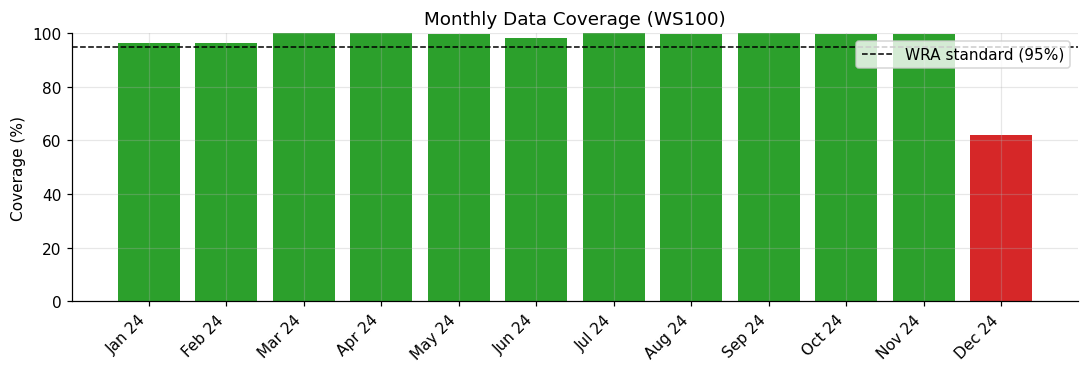

In [5]:
# กราฟตรวจสอบคุณภาพข้อมูล
monthly = clean_data[BASE_SENSOR].notna().resample('MS').mean() * 100
fig, ax = plt.subplots(figsize = (10, 3.5))
ax.bar(
    range(len(monthly)),
    monthly.values,
    color = ['#d62728' if v < 80 else '#ff7f0e' if v < 95 else '#2ca02c' for v in monthly]
    )
ax.axhline(95, color = 'k', ls = '--', lw = 1, label = 'WRA standard (95%)')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels([d.strftime('%b %y') for d in monthly.index], rotation = 45, ha = 'right')
ax.set_ylabel('Coverage (%)')
ax.set_ylim(0, 100)
ax.set_title(f'Monthly Data Coverage ({BASE_SENSOR})')
ax.legend()
plt.tight_layout()
data_io.save_image(fig, 'monthly_coverage')
plt.show(fig)

## Cell 6 Feature + Alpha + Train Vertical

In [6]:
feature = features.build_features(clean_data)
feature, ALPHA = features.compute_alpha(feature)
train_model, test_model = features.split_by_time(feature)

used = len(train_model) + len(test_model)
show(
    'FEATURE',
    Alpha = f"{ALPHA:.4f}",
    Model_usable = f"{used:,}/{len(feature):,} ({used/len(feature) * 100:.1f}%)",
    Train_model = f"{len(train_model):,}",
    Test_model = f"{len(test_model):,}",
    )

# train_all: Power Law baseline + Model ใน build_models() + กลุ่ม Model ที่ทำนาย alpha
# height_lower / upper ไม่ต้องส่ง จะอ่านค่าจาก config เอง
scores_model, trained_model = models.train_all(train_model, test_model, FEATURES, TARGET_HEIGHT, ALPHA)
display(scores_model)

BEST_MODEL = scores_model.index[0] # เรียง RMSE จากน้อยไปมาก
base_mape = scores_model.loc['Power Law (baseline)', 'MAPE']
show(
    'MODEL',
    Best_model = BEST_MODEL,
    RMSE = f"{scores_model.loc[BEST_MODEL, 'RMSE']:.4f}",
    MAPE = f"{scores_model.loc[BEST_MODEL, 'MAPE']:.2f}%",
    โมเดลที่ผ่านเกณฑ์_20 = ('Pass' if scores_model.loc[BEST_MODEL, 'MAPE'] <= 20 else 'Not Pass'),
    โมเดลที่ดีกว่า_baseline = f"{(1 - scores_model.loc[BEST_MODEL, 'MAPE']/base_mape)*100:.1f}%",
    )

[FEATURE]Alpha = 0.2241 | Model_usable = 29,607/52,704 (56.2%) | Train_model = 20,725 | Test_model = 8,882


,MAE,RMSE,MAPE,R2
model,,,,
HistgradientBoosting,0.4559,0.6302,7.8655,0.9207
QGB pass α,0.4493,0.6333,7.9388,0.9199
Random Forest,0.4640,0.6425,7.8629,0.9176
LightGBM,0.4685,0.6454,8.1356,0.9169
Random Forest pass α,0.4685,0.6496,7.8396,0.9158
Linear Regression,0.4760,0.6523,8.0356,0.9151
Quantile GB (median),0.4699,0.6543,8.1454,0.9145
XGBoost,0.4992,0.6865,8.7651,0.9059
MLP pass α,0.5574,0.7559,8.9021,0.8859


[MODEL]Best_model = HistgradientBoosting | RMSE = 0.6302 | MAPE = 7.87% | โมเดลที่ผ่านเกณฑ์_20 = Pass | โมเดลที่ดีกว่า_baseline = 28.4%


## Cell 7 Predict ค่าลมที่ hub height

### 7-A จะมี 2 เวอร์ชัน

In [7]:
# Predict ลมที่ hub height จาก Model ที่ดีที่สุด
key_model = next((key for key, (lab, _) in models.build_models().items() if lab == BEST_MODEL), None)

if key_model: # Model predict wind
    wind_hub = pd.Series(models.predict_hub_wind(
        trained_model[key_model],
        feature[FEATURES].dropna(),
        'direct',
        BASE_SENSOR,
        BASE_HEIGHT,
        HUB_HEIGHT,
    ),
    index = feature[FEATURES].dropna().index)
else:
    key_model = {
        'Ramdom Forest pass alpha': 'random_forest_alpha',
        'MLP pass alpha': 'mlp_alpha',
        'QGB pass alpha': 'qgb_alpha',
    }[BEST_MODEL]
    wind_hub = pd.Series(models.predict_hub_wind(
        trained_model[key_model],
        feature[FEATURES].dropna(),
        'alpha',
        BASE_SENSOR,
        BASE_HEIGHT,
        HUB_HEIGHT,
    ), 
    index = feature[FEATURES].dropna().index)

measured_model = clean_data[TARGET_HEIGHT].dropna() # แบบ Model ที่ผ่านการวัดค่าแล้ว
sd_ratio = wind_hub.std() / measured_model.std()
if sd_ratio < 0.9:
    wind_hub = (wind_hub.mean() + (wind_hub - wind_hub.mean()) / sd_ratio).clip(lower = 0.1)
    show(
        'VARIANCE',
        squeeze_model = f"{(1 - sd_ratio)*100:.0f}%",
        fixed = 'ปรับค่าลมให้กลับเท่าค่าลมวัดจริง',
        )

    show(
        'Hub Height',
        Height = f"{HUB_HEIGHT} ม.",
        Type = ('interpolation' if HUB_HEIGHT <= SITE['mast_height_m'] else 'extrapolation'),
        wind_mean = f"{wind_hub.mean():.3f} m/s",
        sd = f"{wind_hub.std():.3f}",
        )

[VARIANCE]squeeze_model = 21% | fixed = ปรับค่าลมให้กลับเท่าค่าลมวัดจริง
[Hub Height]Height = 150 ม. | Type = interpolation | wind_mean = 5.388 m/s | sd = 2.400


### 7-B Version MCP

In [8]:
# MCP: ขยายข้อมูล 1 ปีเป็นค่าลมระยะยาว 20 ปี
MCP_COLS = ['era_ws', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos']

def mcp_features(df):
    """ เพิ่ม feature เวลาให้ MCP - ฤดูกาล (dayofyear) และเวลาในวัน (hour) """
    output = df.copy()
    output['month_sin'] = np.sin(2 * np.pi * output.index.dayofyear / 365)
    output['month_cos'] = np.cos(2 * np.pi * output.index.dayofyear / 365)
    output['hour_sin'] = np.sin(2 * np.pi * output.index.hour / 24)
    output['hour_cos'] = np.cos(2 * np.pi * output.index.hour / 24)
    return output

# จับคู่ ERA5 กับลม hub ในช่วงที่ทับกัน
overlap = mcp_features(era5_data.join(wind_hub.resample('1h').mean().rename('site'), how = 'inner').dropna())
cut_data = overlap.index[int(len(overlap) * 0.70)]
mcp = models.make_random_forest(min_samples_leaf = 10).fit(overlap.loc[:cut_data, MCP_COLS], overlap.loc[:cut_data, 'site'])
mcp_score = models.evaluate(overlap.loc[cut_data:, 'site'], mcp.predict(overlap.loc[cut_data:, MCP_COLS]), 'MCP')

# raw correlation - เอาไว้ดูว่า ERA5 กับ Site ค่าสัมพันธ์กันไหม
r2_hour = overlap['era_ws'].corr(overlap['site'])
r2_day = overlap.resample('D').mean().dropna().pipe(lambda d:d['era_ws'].corr(d['site']))
show(
    'MCP', 
    R2_hour = f"{r2_hour:.3f}",
    R2_day = f"{r2_day:.3f}",
    R2 = f"{mcp_score['R2']:.3f}",
    RMSE = f"{mcp_score['RMSE']:.3f}",
    )

# VALIDATION Gate - กรณี R2 ติดลบ
MCP_OK = mcp_score['R2'] >= 0.5
if not MCP_OK:
    print(f"\nMCP ไม่ผ่าน (R2 = {mcp_score['R2']:.3f} เพราะค่าต้อง >= 0.5)")

[MCP]R2_hour = 0.036 | R2_day = 0.095 | R2 = -1.111 | RMSE = 3.345

MCP ไม่ผ่าน (R2 = -1.111 เพราะค่าต้อง >= 0.5)


### 7-C Version No MCP

In [9]:
# ไม่ทำ MCP กรณี overlap ไม่สัมพันธ์กับข้อมูล
MCP_OK = False
show(
    'MCP',
    status = 'cross',
    reason = 'ERA5 ไม่สัมพันธ์กับข้อมูลตรวจวัด',
    )

[MCP]status = cross | reason = ERA5 ไม่สัมพันธ์กับข้อมูลตรวจวัด


## Cell 8 คำนวณ IAV + Weibull

In [10]:
# IAV: ความผันผวนรายปี
annual = era5_data['era_ws'].resample('YS').mean()
annual = annual[era5_data['era_ws'].resample('YS').size() > 8000] # ตัดปีที่ข้อมูลไม่ครบ
IAV = float(annual.std() / annual.mean())
show(
    'IAV',
    value = f"{IAV * 100:.2f}%",
    from_year = f"{len(annual)} year",
    value_normal = '3-6%' if 0.03 <= IAV <= 0.06 else 'Abnormal',
    )

# Weibull
k, A_meas = energy.fit_weibull(wind_hub)
if MCP_OK:
    longterm = mcp_features(era5_data)
    longterm['wind_lt'] = mcp.predict(longterm[MCP_COLS])
    ration = longterm['wind_lt'].mean() / wind_hub.mean() # ปรับระดับตามค่าระยะยาว
    A = A_meas * ration
    show(
        'LONGTERM',
        ปรับระดับข้อมูล = f"x{ration:.4f}",
        ปีที่ใช้วัดเทียบกับค่าระยะยาว = f"{(1 / ration - 1) * 100:+.2f}%",
        )
else:
    A = A_meas # ไม่ปรับใช้ปีที่วัด วัดโดยตรง
    rho = energy.air_density(clean_data['Temp'].median(), clean_data['Pres'].median())
    aep = energy.calculate_aep(k, A, rho)
    show(
        'WEIBULL',
        value_k = f"{k:.3f}",
        value_A = f"{A:.3f}",
        wind_mean = f"{energy.weibull_mean(k,A):.3f} m/s",
        normal = '1.8-2.5' if 1.8 <= k <= 2.5 else 'k Abnormal'
        )
    show(
        'AEP',
        rho = f"{rho:.4f}",
        CF = f"{aep['capacity_factor_pct']:.2f}%",
        net = f"{aep['net_farm_gwh']:.2f} GWh",
        )

[IAV]value = 4.00% | from_year = 20 year | value_normal = 3-6%
[WEIBULL]value_k = 2.384 | value_A = 6.102 | wind_mean = 5.408 m/s | normal = 1.8-2.5
[AEP]rho = 1.1521 | CF = 11.29% | net = 44.52 GWh


## Cell 9 Uncertainty + P50/P75/P90

In [11]:
# แต่ละองค์ประกอบรวมแบบ root-sum-square
UNCERTAINTY = {
    'measurement': .03, # ความแม่นของเซนเซอร์
    'vertical': .04, # การขยายลมตามความสูง
    'power_curve': .05, # ความคลาดเคลื่อนของ power curve
    'wake': .03, # การประเมิน wake loss
    'iav': IAV,
}

# ไม่ทำ MCP = ไม่รู้ว่าปีที่วัดค่าปกติไหม เลยต้องบวกค่าความไม่แน่นอนลงไป
UNCERTAINTY['mcp' if MCP_OK else 'long_term_adjustment'] = .035 if MCP_OK else .06
p = energy.exceedance_levels(aep['net_farm_gwh'], UNCERTAINTY)
pxx = energy.exceedance_table(p['P50'], p['sigma_total'])
display(pxx)

show(
    'SIGMA',
    sum = f"{p['sigma_total'] * 100:.2f}%",
    normal = '8-12%'
    )

show(
    'P50/P75/P90',
    P50 = f"{p['P50']:.2f}",
    P75 = f"{p['P75']:.2f}",
    P90 = f"{p['P90']:.2f}",
    unit = 'GWh/year',
    P90_far_P50 = f"{(p['P90']-1)*100:.1f}%"
    )

,Exceedance (%),AEP (GWh/year),z-score,vs P50 (%)
Level,,,,
P50,50.0,44.52,0.000,0.00
P75,75.0,41.36,0.674,-7.11
P90,90.0,38.51,1.282,-13.50


[SIGMA]sum = 10.54% | normal = 8-12%
[P50/P75/P90]P50 = 44.52 | P75 = 41.36 | P90 = 38.51 | unit = GWh/year | P90_far_P50 = 3751.0%


## Cell 10 คำนวณการเงิน

In [13]:
capacity_mw = energy.DEFAULT_TURBINE['rated_kw'] * energy.DEFAULT_TURBINE['num_turbines'] / 1000
rows = []
for lab in ['P50', 'P75', 'P90']:
    row = finance.financial_analysis(p[lab], capacity_mw)
    rows.append({
        'Level': lab,
        'AEP (GWh)': round(p[lab], 2),
        'NPV (MTHB)': round(row['NPV_mthb'], 2),
        'IRR (%)': round(row['IRR_pct'], 2) if pd.notna(row['IRR_pct']) else None,
        'Payback (year)': row['payback_years'],
        'LCOE (THB/kWh)': round(row['LCOE_thb_per_kwh'], 2)
    })

finance_table = pxx[['Exceedance (%)', 'z-score', 'vs P50 (%)']].join(pd.DataFrame(rows).set_index('Level'))
display(finance_table)

r90 = finance.financial_analysis(p['P90'], capacity_mw)
show(
    'Finance P90',
    NPV = f"{r90['NPV_mthb']:.1f} million bath",
    LCOE = f"{r90['LCOE_thb_per_kwh']:.2f} bath/kWh",
    PPA = f"{finance.DEFAULT_ECONOMICS['ppa_thb_per_kwh']:.2f} bath/kWh",
    summary = ('คุ้มค่า' if r90['NPV_mthb'] > 0 else 'ไม่คุ้มค่า')
    )

,Exceedance (%),z-score,vs P50 (%),AEP (GWh),NPV (MTHB),IRR (%),Payback (year),LCOE (THB/kWh)
Level,,,,,,,,
P50,50.0,0.000,0.00,44.52,-1465.53,-5.32,None,6.47
P75,75.0,0.674,-7.11,41.36,-1555.52,-6.73,None,6.97
P90,90.0,1.282,-13.50,38.51,-1636.51,-8.18,None,7.48


[Finance P90]NPV = -1636.5 million bath | LCOE = 7.48 bath/kWh | PPA = 3.00 bath/kWh | summary = ไม่คุ้มค่า


## Cell 11 Result Graph and Save image

Save: 013054_20260903_081653/weibull_aep.png


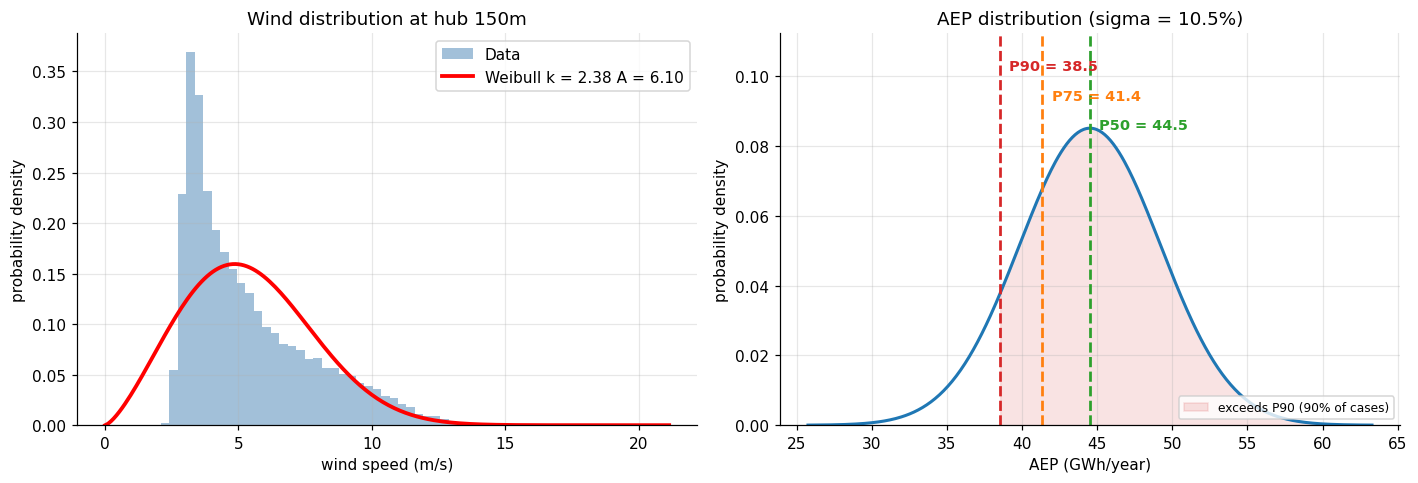

In [14]:
from scipy import stats
fig, ax = plt.subplots(1, 2, figsize = (13, 4.5))

# กราฟซ้าย: Weibull fit เทียบกับข้อมูลจริง
v = wind_hub.dropna().to_numpy()
v = v[v > 0]
ax[0].hist(v, bins = 60, density = True, alpha = .5, color = 'steelblue', label = 'Data')
x = np.linspace(0, v.max(), 200)
ax[0].plot(x, stats.weibull_min.pdf(x, k, 0, A), 'r-', lw = 2.5, label = f'Weibull k = {k:.2f} A = {A:.2f}')
ax[0].set_xlabel('wind speed (m/s)')
ax[0].set_ylabel('probability density')
ax[0].set_title(f'Wind distribution at hub {HUB_HEIGHT}m')
ax[0].legend()

# กราฟฝั่งขวา: แสดงการแจกแจงของ AEP + เส้นกราฟ P50/P75/P90
dist = energy.aep_distribution(p['P50'], p['sigma_total'])
colors = {'P50': '#2ca02c', 'P75': '#ff7f0e', 'P90': '#d62728'}
ax[1].plot(dist['x'], dist['pdf'], color = '#1f77b4', lw = 2)
over = dist['x'] >= pxx.loc['P90', 'AEP (GWh/year)']
ax[1].fill_between(dist['x'][over], dist['pdf'][over], color = '#d62728', alpha = .13, label = 'exceeds P90 (90% of cases)')
top = dist['pdf'].max()

for lv, c in colors.items():
    val = pxx.loc[lv, 'AEP (GWh/year)']
    ax[1].axvline(val, color = c, ls = '--', lw = 1.8)
    ax[1].annotate(f'{lv} = {val:.1f}', (val, top * {'P90': 1.21, 'P75': 1.11, 'P50': 1.01}[lv]), textcoords = 'offset points', xytext = (6, 0), color = c, fontweight = 'bold', fontsize = 9.5, va = 'center')
ax[1].set_ylim(0, top * 1.32)
ax[1].set_xlabel('AEP (GWh/year)')
ax[1].set_ylabel('probability density')
ax[1].set_title(f"AEP distribution (sigma = {p['sigma_total'] * 100:.1f}%)")
ax[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
data_io.save_image(fig, 'weibull_aep')
plt.show()

## Cell 12 Save Result + Summary

In [15]:
data_io.save_output(scores_model, 'model_scores')
data_io.save_output(pxx, 'exceedance_PXX')
data_io.save_output(finance_table, 'finance_PXX')

summary = pd.DataFrame([{
    'site': SITE['station_code'],
    'data_version': DATA_VERSION,
    'mcp_used': MCP_OK,
    'best_model': BEST_MODEL,
    'alpha': round(ALPHA, 4),
    'weibull_k': round(k, 3),
    'weibull_A': round(A, 3),
    'iav_pct': round(IAV * 100, 2),
    'sigma_total_pct': round(p['sigma_total'] * 100, 2),
    'capacity_factor_pct': round(aep['capacity_factor_pct'], 2),
    'P50_GWh': round(p['P50'], 2),
    'P75_GWh': round(p['P75'], 2),
    'P90_GWh': round(p['P90'], 2),
    'NPV_P90_MTHB': round(r90['NPV_mthb'], 1),
    'LCOE_P90_THB_kWh': round(r90['LCOE_thb_per_kwh'], 2),
}])

data_io.save_output(summary, 'site_summary')
display(summary.T)
print(f"\nResult: {data_io.run_dir()}")

Save: 013054_20260903_081653/model_scores.csv
Save: 013054_20260903_081653/exceedance_PXX.csv
Save: 013054_20260903_081653/finance_PXX.csv
Save: 013054_20260903_081653/site_summary.csv


,0
site,013054
data_version,013054_03092026_0816_8a2429e9
mcp_used,False
best_model,HistgradientBoosting
alpha,0.2241
weibull_k,2.384
weibull_A,6.102
iav_pct,4.0
sigma_total_pct,10.54
capacity_factor_pct,11.29



Result: /home/jovyan/project/data/outputs/013054_20260903_081653
